<a href="https://colab.research.google.com/github/zer0punch/zer0punch/blob/practice_1/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задача 1

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv("fake_news.csv")
texts = df["text"].astype(str)
labels = df["label"]

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=5
)

X_train = vectorizer.fit_transform(X_train_texts)
X_test = vectorizer.transform(X_test_texts)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

clf = PassiveAggressiveClassifier(
    C=1.0,
    max_iter=1000,
    loss="hinge"
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Train shape: (5068, 21694)
Test shape: (1267, 21694)
Accuracy: 0.9455406471981057
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.95       633
        REAL       0.95      0.94      0.95       634

    accuracy                           0.95      1267
   macro avg       0.95      0.95      0.95      1267
weighted avg       0.95      0.95      0.95      1267



### Матрица ошибок

<Figure size 500x500 with 0 Axes>

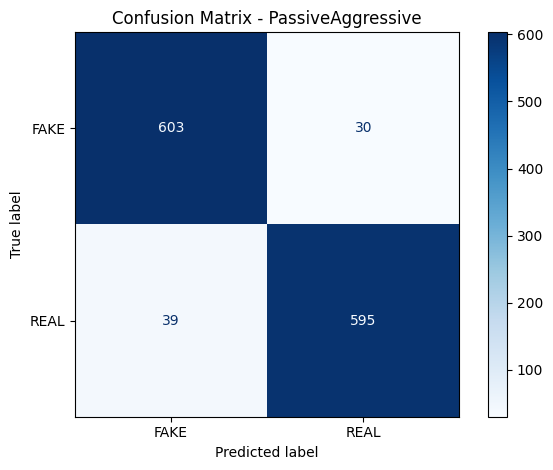

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)

plt.figure(figsize=(5, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - PassiveAggressive")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


### Визуализация самых важных признаков

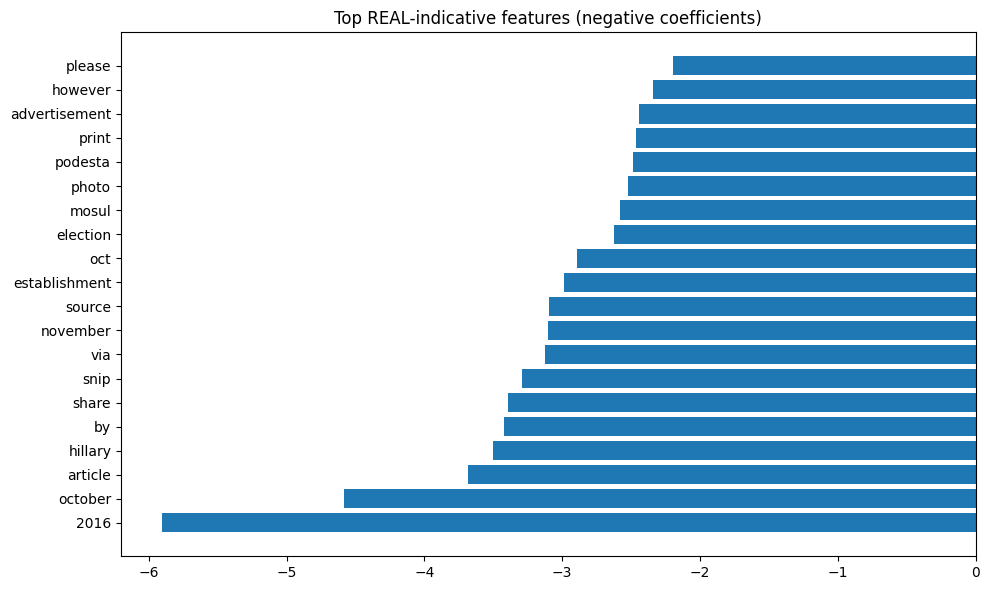

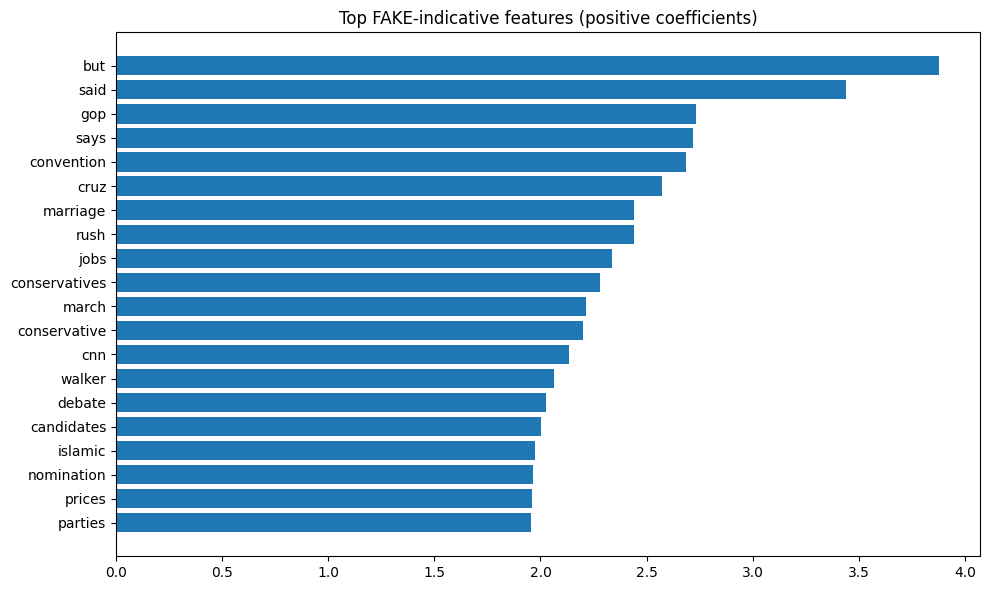

In [3]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

def plot_top_features(coefs, feature_names, top_n=20):
    top_fake_idx = np.argsort(coefs)[-top_n:]
    top_real_idx = np.argsort(coefs)[:top_n]

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), coefs[top_real_idx], align="center")
    plt.yticks(range(top_n), feature_names[top_real_idx])
    plt.title("Top REAL-indicative features (negative coefficients)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), coefs[top_fake_idx], align="center")
    plt.yticks(range(top_n), feature_names[top_fake_idx])
    plt.title("Top FAKE-indicative features (positive coefficients)")
    plt.tight_layout()
    plt.show()

plot_top_features(coefs, feature_names, top_n=20)